# Data and Library Preparation

In [1]:
import sys
from pathlib import Path

# Add parent directory of "a" to sys.path
sys.path.append(str(Path.cwd().parent.parent.parent))

In [2]:
import numpy as np
import pandas as pd
from CODECbreakCode.AudioMixer import SingleFileAudioMixer
import CODECbreakCode.Evaluator as Evaluator
from CODECbreakCode.Evaluator import MeasureHAAQIOutput
import argparse

In [3]:
import signalcomparison as sc
import signalmaskcomparison as smc
import os
import re
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Audio

import rich
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Original Reading Fold
SpeechMix_Mixing_Path = './Experiment.A.Audio/'
## Degradation Configuration
solution = [15,30,2,-15,10,0.1,50]

## MP3

### Clean MP3

In [5]:
SpeechMix_Noise_Generator_MP3 = SingleFileAudioMixer(SpeechMix_Mixing_Path,"Male_English.wav")
SpeechMix_Referece_File,_ = SpeechMix_Noise_Generator_MP3.TestDynNoisedFullTrack([0]*7,"Reference_IN_Male_English.wav")
print(f"Referece_File:{SpeechMix_Referece_File}")
Referece_MP3File = Evaluator.Mp3LameLossyCompress(SpeechMix_Referece_File,64)
print(f"Reggae_Referece_Mp3File:{Referece_MP3File}")
####initalise the Haaqi
MeasureHAAQI = MeasureHAAQIOutput(Referece_MP3File)#Initilize the HAAQI with a permanent reference
MeasureHAAQI.MeasureHAQQIOutput(Referece_MP3File) #Test on how far from itself to itself

Audio duration orginal is 8.0 seconds
Referece_File:./Experiment.A.Audio//Mixing_Result/Reference_IN_Male_English.wav
Reggae_Referece_Mp3File:./Experiment.A.Audio/Mixing_Result_Mp3_Wav/Reference_IN_Male_English_64kbps.wav


0.9989990004643419

In [6]:
acuum_spl_orig_wav, accum_global_mask_wav, accum_noise_mask_wav, accum_tone_mask_wav, acuum_mask_degr_wav, acuum_smr_orig_wav,block_index_wav = smc.generate_mask(SpeechMix_Referece_File)
acuum_spl_orig_mp3, accum_global_mask_mp3, accum_noise_mask_mp3, accum_tone_mask_mp3, acuum_mask_degr_mp3, acuum_smr_orig_mp3, block_index_mp3 = smc.generate_mask(Referece_MP3File)

### Clean Mp3 Adding degradation

In [7]:
degradated_filename = "worst_speech_degraded.wav"
gener_Audio,_ = SpeechMix_Noise_Generator_MP3.TestDynNoisedFullTrack(solution,degradated_filename)
gener_Audio_mp3 = Evaluator.Mp3LameLossyCompress(gener_Audio, 64)
score = MeasureHAAQI.MeasureHAQQIOutput(gener_Audio_mp3)
1-score

/root/anaconda3/envs/codecbreak/lib/python3.10/site-packages/audiomentations/core/transforms_interface.py:107: UserWarning: Warning: input samples dtype is np.float64. Converting to np.float32
  warnings.warn(


0.5631688173329279

In [8]:
acuum_spl_orig_wav_deg, accum_global_mask_wav_deg, accum_noise_mask_wav_deg, accum_tone_mask_wav_deg, acuum_mask_degr_wav_deg, acuum_smr_orig_wav_deg,block_index_wav_deg = smc.generate_mask(gener_Audio)
acuum_spl_orig_mp3_deg, accum_global_mask_mp3_deg, accum_noise_mask_mp3_deg, accum_tone_mask_mp3_deg, acuum_mask_degr_mp3_deg, acuum_smr_orig_mp3_deg, block_index_mp3_deg = smc.generate_mask(gener_Audio_mp3)

## AAC

### Clean AAC

In [9]:
SpeechMix_Noise_Generator_AAC = SingleFileAudioMixer(SpeechMix_Mixing_Path,"Male_English.wav")
SpeechMix_Referece_File,_ = SpeechMix_Noise_Generator_AAC.TestDynNoisedFullTrack([0]*7,"Reference_IN_Male_English.wav")
print(f"Referece_File:{SpeechMix_Referece_File}")
Referece_AACFile = Evaluator.AacLameLossyCompress(SpeechMix_Referece_File,64)
print(f"Reggae_Referece_AACFile:{Referece_AACFile}")
####initalise the Haaqi
MeasureHAAQI = MeasureHAAQIOutput(Referece_AACFile)#Initilize the HAAQI with a permanent reference
MeasureHAAQI.MeasureHAQQIOutput(Referece_AACFile) #Test on how far from itself to itself

Audio duration orginal is 8.0 seconds
Referece_File:./Experiment.A.Audio//Mixing_Result/Reference_IN_Male_English.wav
Reggae_Referece_AACFile:./Experiment.A.Audio/Mixing_Result_AAC_Wav/Reference_IN_Male_English_64kbps.wav


0.9989990225260555

In [10]:
acuum_spl_orig_wav, accum_global_mask_wav, accum_noise_mask_wav, accum_tone_mask_wav, acuum_mask_degr_wav, acuum_smr_orig_wav,block_index_wav = smc.generate_mask(SpeechMix_Referece_File)
acuum_spl_orig_aac, accum_global_mask_aac, accum_noise_mask_aac, accum_tone_mask_aac, acuum_mask_degr_aac, acuum_smr_orig_aac, block_index_aac = smc.generate_mask(Referece_AACFile)

### Clean AAC Adding degradation

In [11]:
degradated_filename = "worst_speech_degraded.wav"
gener_Audio,_ = SpeechMix_Noise_Generator_AAC.TestDynNoisedFullTrack(solution,degradated_filename)
gener_Audio_aac = Evaluator.AacLameLossyCompress(gener_Audio, 64)
score = MeasureHAAQI.MeasureHAQQIOutput(gener_Audio_aac)
1-score

/root/anaconda3/envs/codecbreak/lib/python3.10/site-packages/audiomentations/core/transforms_interface.py:107: UserWarning: Warning: input samples dtype is np.float64. Converting to np.float32
  warnings.warn(


0.5532055321238909

In [12]:
acuum_spl_orig_wav_deg, accum_global_mask_wav_deg, accum_noise_mask_wav_deg, accum_tone_mask_wav_deg, acuum_mask_degr_wav_deg, acuum_smr_orig_wav_deg,block_index_wav_deg = smc.generate_mask(gener_Audio)
acuum_spl_orig_aac_deg, accum_global_mask_aac_deg, accum_noise_mask_aac_deg, accum_tone_mask_aac_deg, acuum_mask_degr_aac_deg, acuum_smr_orig_aac_deg, block_index_aac_deg = smc.generate_mask(gener_Audio_aac)

## EnCODEC

### Clean EnCODEC

In [13]:
SpeechMix_Noise_Generator_NC = SingleFileAudioMixer(SpeechMix_Mixing_Path,"Male_English.wav")
SpeechMix_Referece_File,_ = SpeechMix_Noise_Generator_NC.TestDynNoisedFullTrack([0]*7,"Reference_IN_Male_English.wav")
print(f"Referece_File:{SpeechMix_Referece_File}")
Referece_NCFile = Evaluator.NeuralCodecCompress(SpeechMix_Referece_File)
print(f"Reggae_Referece_AACFile:{Referece_NCFile}")
####initalise the Haaqi
MeasureHAAQI = MeasureHAAQIOutput(Referece_NCFile)#Initilize the HAAQI with a permanent reference
MeasureHAAQI.MeasureHAQQIOutput(Referece_NCFile) #Test on how far from itself to itself

Audio duration orginal is 8.0 seconds
Referece_File:./Experiment.A.Audio//Mixing_Result/Reference_IN_Male_English.wav
Reggae_Referece_AACFile:/home/codecrack/CodecBreakerwithRL/Exp.3.CODECFight/Paper_Code_Effect_of_Degradations_on_CODECs/Experiment.A/Experiment.A.Audio/Mixing_Result_NeuralCodec_Wav/Reference_IN_Male_English_24kbps.wav


0.9989999419174526

In [14]:
acuum_spl_orig_wav, accum_global_mask_wav, accum_noise_mask_wav, accum_tone_mask_wav, acuum_mask_degr_wav, acuum_smr_orig_wav,block_index_wav = smc.generate_mask(str(SpeechMix_Referece_File))
acuum_spl_orig_nc, accum_global_mask_nc, accum_noise_mask_nc, accum_tone_mask_nc, acuum_mask_degr_nc, acuum_smr_orig_nc, block_index_nc = smc.generate_mask(str(Referece_NCFile))

### Clean Neural CODEC Adding degradation

In [15]:
degradated_filename = "worst_speech_degraded.wav"
gener_Audio,_ = SpeechMix_Noise_Generator_NC.TestDynNoisedFullTrack(solution,degradated_filename)
gener_Audio_Neural = Evaluator.NeuralCodecCompress(gener_Audio)
score = MeasureHAAQI.MeasureHAQQIOutput(gener_Audio_Neural)
1-score

/root/anaconda3/envs/codecbreak/lib/python3.10/site-packages/audiomentations/core/transforms_interface.py:107: UserWarning: Warning: input samples dtype is np.float64. Converting to np.float32
  warnings.warn(


0.6830490205704681

In [16]:
acuum_spl_orig_wav_deg, accum_global_mask_wav_deg, accum_noise_mask_wav_deg, accum_tone_mask_wav_deg, acuum_mask_degr_wav_deg, acuum_smr_orig_wav_deg,block_index_wav_deg = smc.generate_mask(str(gener_Audio))
acuum_spl_orig_nc_deg, accum_global_mask_nc_deg, accum_noise_mask_nc_deg, accum_tone_mask_nc_deg, acuum_mask_degr_nc_deg, acuum_smr_orig_nc_deg, block_index_nc_deg = smc.generate_mask(str(gener_Audio_Neural))

# Plot

## Clean Plot

### Full Figures

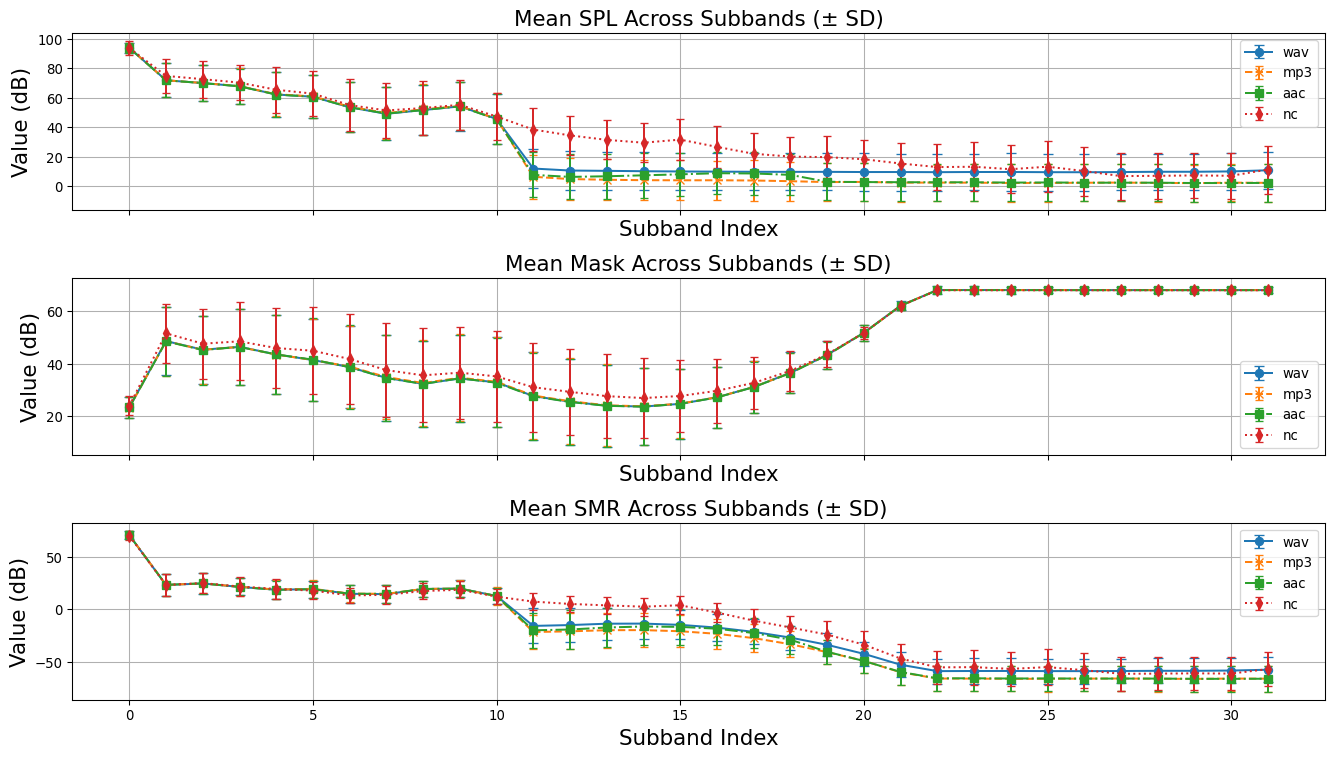

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data shapes for demonstration
data_dict = {
    "SPL": (acuum_spl_orig_wav, acuum_spl_orig_mp3, acuum_spl_orig_aac, acuum_spl_orig_nc),
    "Mask": (acuum_mask_degr_wav, acuum_mask_degr_mp3, acuum_mask_degr_aac, acuum_mask_degr_nc),
    "SMR": (acuum_smr_orig_wav, acuum_smr_orig_mp3, acuum_smr_orig_aac, acuum_smr_orig_nc),
}

subbands = np.arange(32)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True, dpi=96)
axes = axes.flatten()

# New line styles
styles = [
    ('wav', '-o', 4),   # solid line + circle
    ('mp3', '--x', 3),  # dashed + x
    ('aac', '-.s', 3),  # dash-dot + square
    ('nc',  ':d', 3),   # dotted + diamond
]

for i, (title, (data1, data2, data3, data4)) in enumerate(data_dict.items()):
    datasets = [data1, data2, data3, data4]

    for (label, fmt, cap), data in zip(styles, datasets):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        axes[i].errorbar(
            subbands, mean, yerr=std,
            label=label,
            fmt=fmt,
            capsize=cap,
            linewidth=1.5
        )

    axes[i].set_title(f"Mean {title} Across Subbands (± SD)", fontsize=16)
    axes[i].set_xlabel("Subband Index",fontsize=16)
    axes[i].set_ylabel("Value (dB)",fontsize=16)
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
#plt.suptitle("SPL, Mask, and SMR Comparison", fontsize=16, y=1.01)
plt.show()


### Only SPL SMR Full Figures

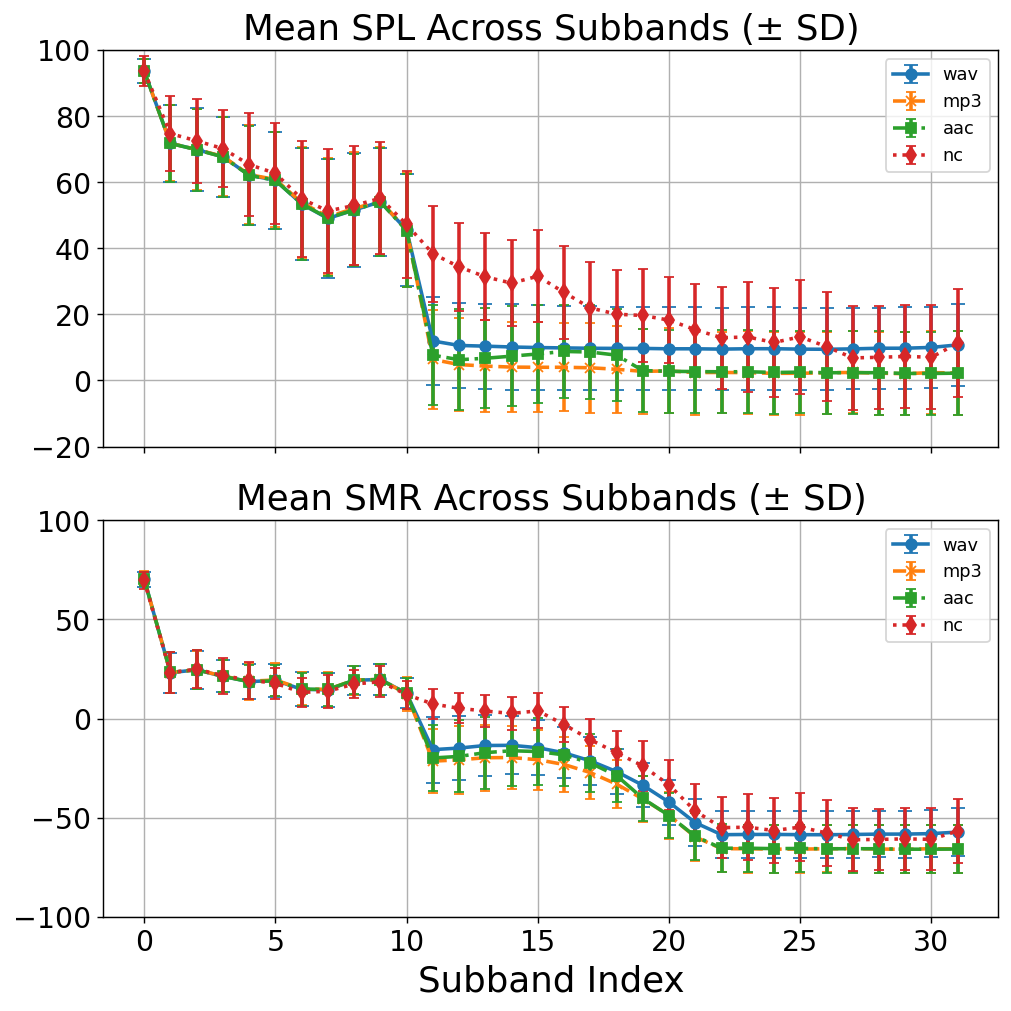

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data shapes for demonstration
data_dict = {
    "SPL": (acuum_spl_orig_wav, acuum_spl_orig_mp3, acuum_spl_orig_aac, acuum_spl_orig_nc),
#    "Mask": (acuum_mask_degr_wav, acuum_mask_degr_mp3, acuum_mask_degr_aac, acuum_mask_degr_nc),
    "SMR": (acuum_smr_orig_wav, acuum_smr_orig_mp3, acuum_smr_orig_aac, acuum_smr_orig_nc),
}

subbands = np.arange(32)
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, dpi=128)
axes = axes.flatten()

# New line styles
styles = [
    ('wav', '-o', 4),   # solid line + circle
    ('mp3', '--x', 3),  # dashed + x
    ('aac', '-.s', 3),  # dash-dot + square
    ('nc',  ':d', 3),   # dotted + diamond
]

for i, (title, (data1, data2, data3, data4)) in enumerate(data_dict.items()):
    datasets = [data1, data2, data3, data4]

    for (label, fmt, cap), data in zip(styles, datasets):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        axes[i].errorbar(
            subbands, mean, yerr=std,
            label=label,
            fmt=fmt,
            capsize=cap,
            linewidth=2
        )

    axes[i].set_title(f"Mean {title} Across Subbands (± SD)", fontsize=20)
#    axes[i].set_ylabel("Value (dB)",fontsize=20)
    axes[i].tick_params(axis='both', labelsize=16)
    axes[i].grid(True)
    axes[i].legend()

axes[i].set_xlabel("Subband Index",fontsize=20)
axes[0].set_ylim(-20, 100)
axes[1].set_ylim(-100, 100)

plt.tight_layout()
#plt.suptitle("SPL, Mask, and SMR Comparison", fontsize=16, y=1.01)
plt.show()


## Degradation Plot

### Full Figures

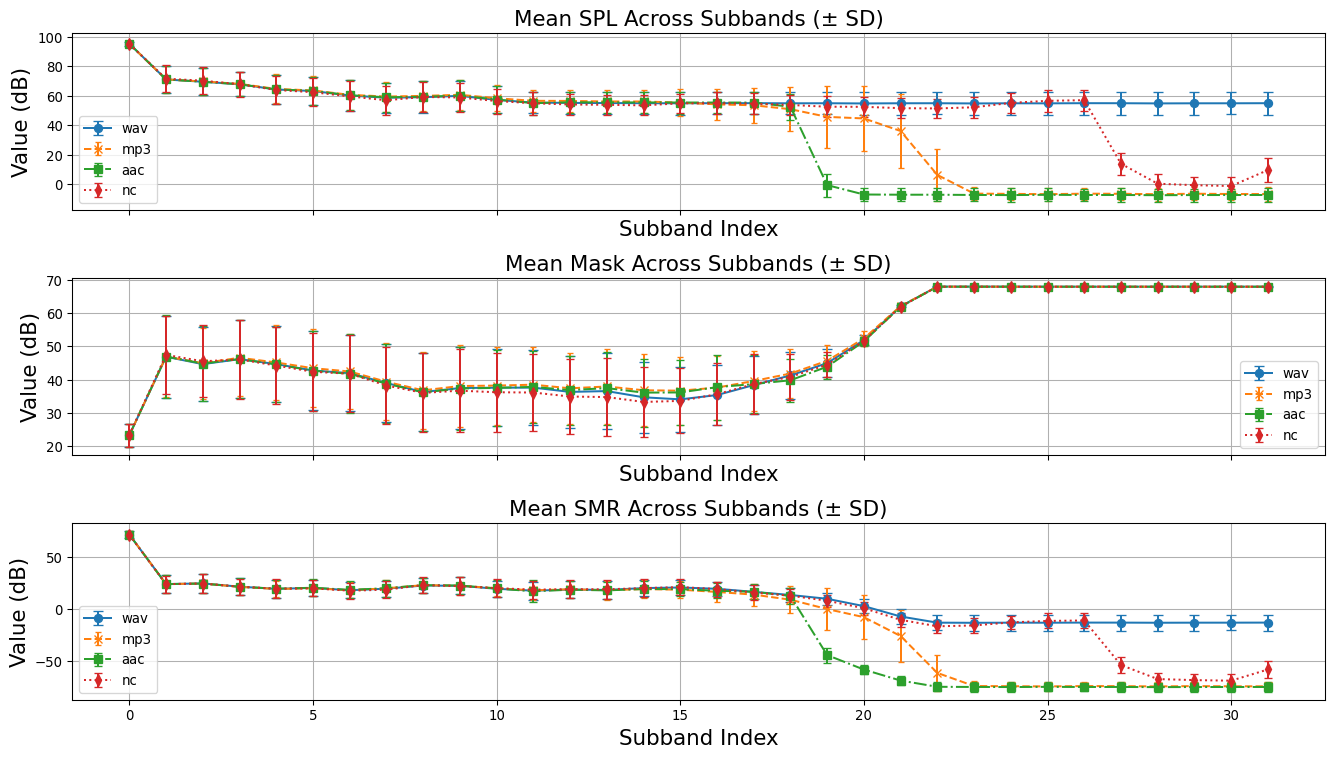

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data shapes for demonstration
data_dict = {
    "SPL": (acuum_spl_orig_wav_deg, acuum_spl_orig_mp3_deg, acuum_spl_orig_aac_deg, acuum_spl_orig_nc_deg),
    "Mask": (acuum_mask_degr_wav_deg, acuum_mask_degr_mp3_deg, acuum_mask_degr_aac_deg, acuum_mask_degr_nc_deg),
    "SMR": (acuum_smr_orig_wav_deg, acuum_smr_orig_mp3_deg, acuum_smr_orig_aac_deg, acuum_smr_orig_nc_deg),
}

subbands = np.arange(32)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True, dpi=96)
axes = axes.flatten()

# New line styles
styles = [
    ('wav', '-o', 4),   # solid line + circle
    ('mp3', '--x', 2),  # dashed + x
    ('aac', '-.s', 3),  # dash-dot + square
    ('nc',  ':d', 3),   # dotted + diamond
]

for i, (title, (data1, data2, data3, data4)) in enumerate(data_dict.items()):
    datasets = [data1, data2, data3, data4]

    for (label, fmt, cap), data in zip(styles, datasets):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        axes[i].errorbar(
            subbands, mean, yerr=std,
            label=label,
            fmt=fmt,
            capsize=cap,
            linewidth=1.5
        )

    axes[i].set_title(f"Mean {title} Across Subbands (± SD)", fontsize=16)
    axes[i].set_xlabel("Subband Index",fontsize=16)
    axes[i].set_ylabel("Value (dB)",fontsize=16)
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
#plt.suptitle("SPL, Mask, and SMR Comparison", fontsize=16, y=1.01)
plt.show()


### Only SPL SMR Full Figures

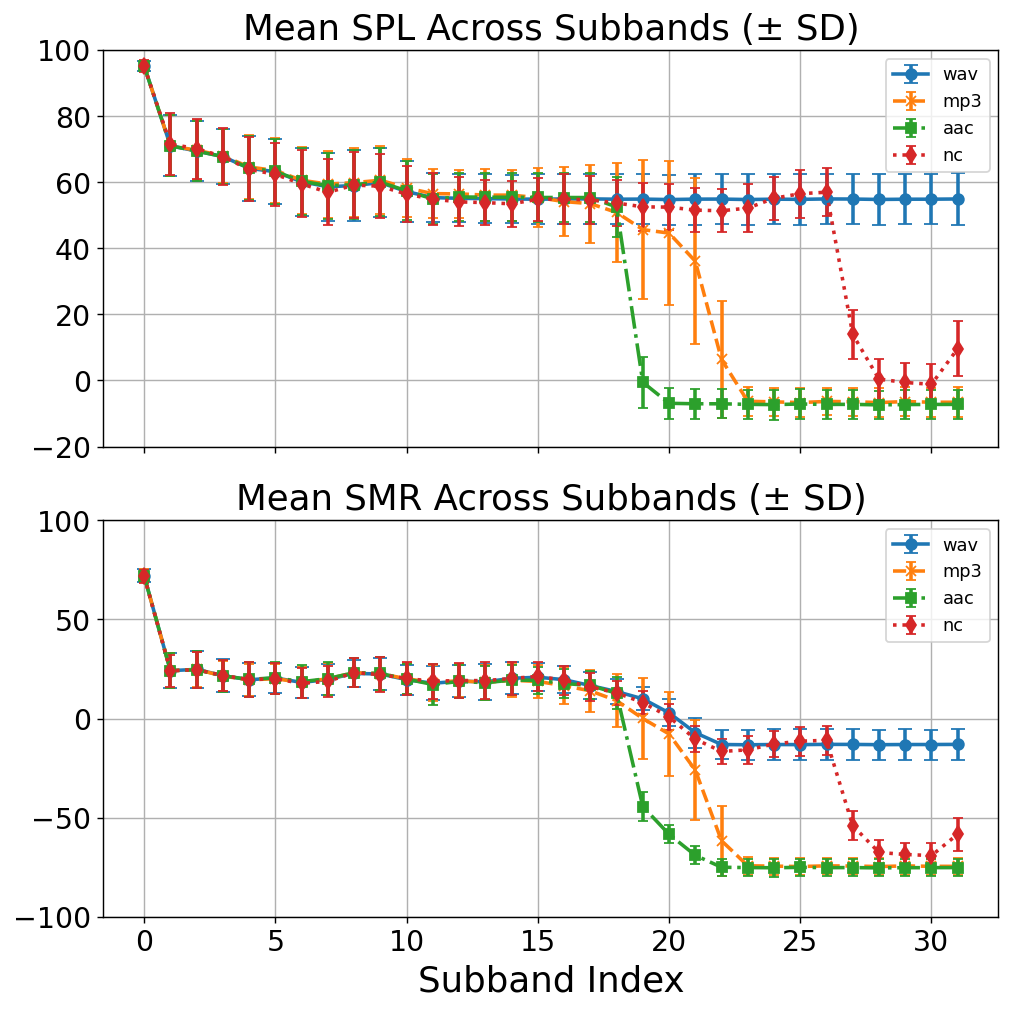

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data shapes for demonstration
data_dict = {
    "SPL": (acuum_spl_orig_wav_deg, acuum_spl_orig_mp3_deg, acuum_spl_orig_aac_deg, acuum_spl_orig_nc_deg),
#    "Mask": (acuum_mask_degr_wav_deg, acuum_mask_degr_mp3_deg, acuum_mask_degr_aac_deg, acuum_mask_degr_nc_deg),
    "SMR": (acuum_smr_orig_wav_deg, acuum_smr_orig_mp3_deg, acuum_smr_orig_aac_deg, acuum_smr_orig_nc_deg),
}

subbands = np.arange(32)
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, dpi=128)
axes = axes.flatten()

# New line styles
styles = [
    ('wav', '-o', 4),   # solid line + circle
    ('mp3', '--x', 3),  # dashed + x
    ('aac', '-.s', 3),  # dash-dot + square
    ('nc',  ':d', 3),   # dotted + diamond
]

for i, (title, (data1, data2, data3, data4)) in enumerate(data_dict.items()):
    datasets = [data1, data2, data3, data4]

    for (label, fmt, cap), data in zip(styles, datasets):
        mean = np.mean(data, axis=0)
        std = np.std(data, axis=0)
        axes[i].errorbar(
            subbands, mean, yerr=std,
            label=label,
            fmt=fmt,
            capsize=cap,
            linewidth=2
        )

    axes[i].set_title(f"Mean {title} Across Subbands (± SD)", fontsize=20)
#    axes[i].set_ylabel("Value (dB)",fontsize=20)
    axes[i].tick_params(axis='both', labelsize=16)
    axes[i].grid(True)
    axes[i].legend()

axes[i].set_xlabel("Subband Index",fontsize=20)
axes[0].set_ylim(-20, 100)
axes[1].set_ylim(-100, 100)

plt.tight_layout()
#plt.suptitle("SPL, Mask, and SMR Comparison", fontsize=16, y=1.01)
plt.show()


# NMR Calculation

## MP3

In [19]:
Evaluator.extract_total_nmr(SpeechMix_Referece_File, Referece_MP3File)

-15.374541

In [20]:
Evaluator.extract_total_nmr(gener_Audio, gener_Audio_mp3)

-7.241533

## AAC

In [21]:
Evaluator.extract_total_nmr(SpeechMix_Referece_File, Referece_AACFile)

-16.895049

In [22]:
Evaluator.extract_total_nmr(gener_Audio, gener_Audio_aac)

-7.651236

## ENCODEC

In [23]:
Evaluator.extract_total_nmr(SpeechMix_Referece_File, Referece_NCFile)

-2.045916

In [24]:
Evaluator.extract_total_nmr(gener_Audio, gener_Audio_Neural)

-3.361109